# Analysis of risk of developing atherosclerotic disease

## Scientific framework
**References**: ADA Standards of Care 2024 • Goff et al., Circulation 2014 (PCE) • NCEP ATP-III • IFCC Guidelines

> **Objective**: *Go beyond static diagnostic cut-offs and model cardiovascular risk as a biological continuum using NHANES 2017-2018 data.*

---


### 1. Imports and configuration

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style = "whitegrid", palette = "muted")
plt.rcParams['figure.dpi'] = 120


### 2. Pre-analytical standardisation notes

Before loading data, it is essential to document the pre-analytical and standardisation constraints that affect the reliability of the biomarkers used in this analysis.

#### HbA1c — NGSP/DCCT Standardisation

- HbA1c values in NHANES are measured with **NGSP-certified** methods, traceable to the **DCCT reference method**.
- This ensures comparability with the ADA diagnostic thresholds ($\ge 6.5\%$).
  - *Limitation*: Haemoglobin variants (HbS, HbC, HbE) and G6PD deficiency can **falsely alter** A1C values independent of actual glycaemia — a source of inter-individual bioinformatic variability.

#### Fasting Plasma Glucose (FPG) — Pre-analytical glycolysis inhibition

- NHANES collects fasting blood in tubes containing **Sodium Fluoride (NaF)** + potassium oxalate, which inhibits the enolase enzyme and blocks *in-vitro* glycolysis.
- Without NaF, glucose degrades $\sim 5–7$ mg/dL/hour at room temperature, causing **false hypoglycaemia**.
  - *Implication for the model*: a single FPG measurement carries intra-individual variability of $\pm 5–10$ mg/dL due to stress, infection, or physical activity. **This is why HbA1c (2–3 month mean) is preferred over FPG as a stability marker.**


### 3. Load NHANES 2017-2018 data (local XPT files)

I downloaded each XPT file from NHANES site since the automated way was not possible. The documentation didn't specify any update way to do it automatically.

In [56]:
path = "../data/2017-2018/"

files = {
    "bmi": "BMX_J.xpt",
    "bp_meds": "BPQ_J.xpt",
    "blood_pressure": "BPX_J.xpt",
    "demographics": "DEMO_J.xpt",
    "hba1c": "GHB_J.xpt",
    "glucose": "GLU_J.xpt",
    "hdl": "HDL_J.xpt",
    "crp": "HSCRP_J.xpt",
    "smoking": "SMQ_J.xpt",
    "cholesterol": "TCHOL_J.xpt",
    "triglycerides": "TRIGLY_J.xpt"
}

dfs = {}
for name, filename in files.items():
    dfs[name] = pd.read_sas(path + filename, format = 'xport', encoding = 'utf-8')
    print(f"- {name}: {dfs[name].shape[0]} rows, {dfs[name].shape[1]} columns")

- bmi: 8704 rows, 21 columns
- bp_meds: 6161 rows, 11 columns
- blood_pressure: 8704 rows, 21 columns
- demographics: 9254 rows, 46 columns
- hba1c: 6401 rows, 2 columns
- glucose: 3036 rows, 4 columns
- hdl: 7435 rows, 3 columns
- crp: 8366 rows, 3 columns
- smoking: 6724 rows, 37 columns
- cholesterol: 7435 rows, 3 columns
- triglycerides: 3036 rows, 10 columns


### 4. Merge all datasets on SEQN (that is the patient ID)

In [57]:
cols = {
    "demographics": ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3"],
    "glucose": ["SEQN", "LBXGLU"],
    "hba1c": ["SEQN", "LBXGH"],
    "cholesterol": ["SEQN", "LBXTC"],
    "hdl": ["SEQN", "LBDHDD"],
    "triglycerides": ["SEQN", "LBXTR", "LBDLDL"],
    "blood_pressure": ["SEQN", "BPXSY1", "BPXDI1"],
    "bmi": ["SEQN", "BMXBMI"],
    "crp": ["SEQN", "LBXHSCRP"],
    "smoking": ["SEQN", "SMQ020"],
    "bp_meds": ["SEQN", "BPQ050A"]
}

df = dfs["demographics"][cols["demographics"]]
for name, col_list in cols.items():
    if name == "demographics":
        continue
    df = df.merge(dfs[name][col_list], on = "SEQN", how = "left")

df.rename(columns = {
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "RIDRETH3": "ethnicity",
    "LBXGLU": "FPG",
    "LBXGH": "HbA1c",
    "LBXTC": "total_chol",
    "LBDHDD": "HDL",
    "LBDLDL": "LDL_nhanes",
    "LBXTR": "triglycerides",
    "BPXSY1": "systolic_bp",
    "BPXDI1": "diastolic_bp",
    "BMXBMI": "BMI",
    "LBXHSCRP": "hs_CRP",
    "SMQ020": "ever_smoked",
    "BPQ050A": "on_bp_meds"
}, inplace=True)

print(f"Merged dataset: {df.shape}")
df.head(3)

Merged dataset: (9254, 16)


,SEQN,age,sex,ethnicity,FPG,HbA1c,total_chol,HDL,triglycerides,LDL_nhanes,systolic_bp,diastolic_bp,BMI,hs_CRP,ever_smoked,on_bp_meds
0,93703.0,2.0,2.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.5,NaN,NaN,NaN
1,93704.0,2.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.7,0.29,NaN,NaN
2,93705.0,66.0,2.0,4.0,NaN,6.2,157.0,60.0,NaN,NaN,NaN,NaN,31.7,2.72,1.0,1.0


### 5. Biochemical quality control — Friedewald & pre-analytical filters

#### LDL-C: Friedewald Formula

The Friedewald equation (Friedewald et al., 1972) estimates LDL-C as:

$$\text{LDL-C} = \text{Total Cholesterol} - \text{HDL-C} - \left(\frac{\text{Triglycerides}}{5}\right)$$

*(The divisor 5 converts TG to VLDL-C assuming a TG:VLDL ratio of 5:1)*

**Validity constraint (NCEP ATP-III)**: The formula is **unreliable when TG > 400 mg/dL** because the TG:VLDL ratio becomes non-linear. In those cases, direct LDL measurement is required.


In [58]:
def calculate_ldl_friedewald(row):
    """Calculates LDL-C via Friedewald formula.
    Returns:
        NaN and flags as invalid if TG > 400 mg/dL (NCEP criterion).
    """
    tc  = row["total_chol"]
    hdl = row["HDL"]
    tg  = row["triglycerides"]

    if pd.isna(tc) or pd.isna(hdl) or pd.isna(tg):
        return np.nan, "missing_data"
    if tg > 400:
        # Formula unreliable: Friedewald assumes constant TG:VLDL ratio
        # which breaks down at high TG (type III/IV dyslipidaemia)
        return np.nan, "TG>400_invalid"
    if tc < 0 or hdl < 0 or tg < 0:
        return np.nan, "negative_value"

    ldl = tc - hdl - (tg / 5.0)
    if ldl < 0:
        return np.nan, "negative_result"
    return ldl, "valid"

results_ldl = df.apply(calculate_ldl_friedewald, axis = 1, result_type = "expand")
df["LDL"] = results_ldl[0]
df["LDL_status"] = results_ldl[1]

# Summary
ldl_summary = df["LDL_status"].value_counts()
print("LDL calculation status:")
print(ldl_summary)
print(f"\nInvalid due to TG>400: {(df['LDL_status'] == 'TG>400_invalid').sum()} patients")
print(f"Valid Friedewald LDL:  {(df['LDL_status'] == 'valid').sum()} patients")

# Compare Friedewald vs NHANES-provided LDL (should be very close)
comparison = df[df["LDL_status"] == "valid"][["LDL", "LDL_nhanes"]].dropna()
corr = comparison.corr().iloc[0,1]
print(f"\nCorrelation Friedewald vs NHANES LDL: r = {corr:.4f}")

LDL calculation status:
LDL_status
missing_data      6420
valid             2808
TG>400_invalid      26
Name: count, dtype: int64

Invalid due to TG>400: 26 patients
Valid Friedewald LDL:  2808 patients

Correlation Friedewald vs NHANES LDL: r = 1.0000


### 6. Data cleaning, A1C stability preference & glycaemic classification

#### 126 mg/dL contextualisation

The ADA threshold of 126 mg/dL for FPG is **not arbitrary**: it was derived as the value above which the prevalence of **diabetic retinopathy** rises sharply (Pima Indians Study, UKPDS).

It is a **retinopathy-predictive threshold**, not a metabolic cliff. This is why the model treats glucose as a **continuous variable**, not a binary cut-off.

#### Intra-individual variability & A1C preference

FPG has a coefficient of variation (CV) of $\sim 5–8%$ within the same individual across days. HbA1c reflects a $2–3$ month glycaemic average and is more stable. When both are available, **HbA1c is used as the primary reliability marker**.


In [59]:
df = df[df["age"] >= 18].copy()
df = df[df["FPG"].between(50, 500)].copy()
df = df[df["HbA1c"].between(3, 15)].copy()

# A1C stability flag
# When A1C is available, it is the preferred primary marker.
# When only FPG is available, we flag it as potentially noisy.
def stability_flag(row):
    """
    Returns:
        the primary glycaemic marker used for classificationand
        a reliability score (higher = more stable).
    """
    if not pd.isna(row["HbA1c"]):
        return "A1C", 1.0     # stable: 2-3 month average
    elif not pd.isna(row["FPG"]):
        return "FPG", 0.6     # less stable: single measurement
    else:
        return "none", 0.0

stab = df.apply(stability_flag, axis=1, result_type = "expand")
df["primary_marker"] = stab[0]
df["marker_stability"] = stab[1]

print("Primary glycaemic marker distribution:")
print(df["primary_marker"].value_counts())
print(f"\nReliability: A1C={df[df['primary_marker'] == 'A1C']['marker_stability'].mean():.1f}, ",
      f"FPG={df[df['primary_marker']=='FPG']['marker_stability'].mean():.1f}")

# Glycaemic classification (ADA 2024)
# Threshold context: 126 mg/dL FPG was chosen as the value above
# which diabetic RETINOPATHY prevalence rises steeply (Pima/UKPDS).
# It is NOT a metabolic switch — damage accumulates continuously from ~100 mg/dL.
def classify_glucose(row):
    fpg = row["FPG"]
    a1c = row["HbA1c"]
    # Diabetes: FPG ≥ 126 mg/dL (retinopathy threshold) OR A1C ≥ 6.5%
    if fpg >= 126 or a1c >= 6.5:
        return "Diabetes"
    # Pre-diabetes: FPG 100-125 mg/dL OR A1C 5.7-6.4%
    # NOTE: vascular damage already begins in this range
    elif fpg >= 100 or a1c >= 5.7:
        return "Pre-diabetes"
    else:
        return "Normal"

df["glucose_status"] = df.apply(classify_glucose, axis = 1)

print(f"\nDataset shape: {df.shape}")
print(df["glucose_status"].value_counts())

Primary glycaemic marker distribution:
primary_marker
A1C    2532
Name: count, dtype: int64

Reliability: A1C=1.0,  FPG=nan

Dataset shape: (2532, 21)
glucose_status
Pre-diabetes    1294
Normal           752
Diabetes         486
Name: count, dtype: int64


### 7. PCE demographic profile mapping

In [60]:
# NHANES RIDRETH3 codes:
# 1 = Mexican American, 2 = Other Hispanic
# 3 = Non-Hispanic White, 4 = Non-Hispanic Black
# 6 = Non-Hispanic Asian, 7 = Other/Multiracial
# PCE validated only for White and Black populations.
# Other ethnicities — White coefficients as best available approximation (Goff et al. 2014).

def get_pce_profile(row):
    eth = row["ethnicity"]
    gender = "male" if row["sex"] == 1 else "female"
    if eth == 4:
        return f"black_{gender}"
    elif eth == 3:
        return f"white_{gender}"
    else:
        return f"white_approx_{gender}"

df["pce_profile"] = df.apply(get_pce_profile, axis=1)
print("PCE profile distribution:")
print(df["pce_profile"].value_counts())

PCE profile distribution:
pce_profile
white_approx_female    583
white_approx_male      512
white_male             431
white_female           419
black_female           310
black_male             277
Name: count, dtype: int64


### 8. PCE coefficients (Goff et al., Circulation 2014)

In [61]:
PCE_COEFFICIENTS = {
    "white_female": {
        "ln_age": -29.799, "ln_age_sq": 4.884,
        "ln_tc": 13.540, "ln_age_x_ln_tc": -3.114,
        "ln_hdl": -13.578, "ln_age_x_ln_hdl": 3.149,
        "ln_sbp_treated": 2.019, "ln_age_x_ln_sbp_tr": 0.000,
        "ln_sbp_untreated": 1.957, "ln_age_x_ln_sbp_untr": 0.000,
        "smoker": 7.574, "ln_age_x_smoker": -1.665,
        "diabetes": 0.661,
        "baseline_survival": 0.9665, "mean_coeff": -29.799,
    },
    "white_male": {
        "ln_age": 12.344, "ln_age_sq": 0.000,
        "ln_tc": 11.853, "ln_age_x_ln_tc": -2.664,
        "ln_hdl": -7.990, "ln_age_x_ln_hdl": 1.769,
        "ln_sbp_treated": 1.797, "ln_age_x_ln_sbp_tr": 0.000,
        "ln_sbp_untreated": 1.764, "ln_age_x_ln_sbp_untr": 0.000,
        "smoker": 7.837, "ln_age_x_smoker": -1.795,
        "diabetes": 0.658,
        "baseline_survival": 0.9144, "mean_coeff": 61.180,
    },
    "black_female": {
        "ln_age": 17.114, "ln_age_sq": 0.000,
        "ln_tc": 0.940, "ln_age_x_ln_tc": 0.000,
        "ln_hdl": -18.920, "ln_age_x_ln_hdl": 4.475,
        "ln_sbp_treated": 29.291, "ln_age_x_ln_sbp_tr": -6.432,
        "ln_sbp_untreated": 27.820, "ln_age_x_ln_sbp_untr": -6.087,
        "smoker": 0.874, "ln_age_x_smoker": 0.000,
        "diabetes": 0.874,
        "baseline_survival": 0.9533, "mean_coeff": 86.608,
    },
    "black_male": {
        "ln_age": 2.469, "ln_age_sq": 0.000,
        "ln_tc": 0.302, "ln_age_x_ln_tc": 0.000,
        "ln_hdl": -0.307, "ln_age_x_ln_hdl": 0.000,
        "ln_sbp_treated": 1.916, "ln_age_x_ln_sbp_tr": 0.000,
        "ln_sbp_untreated": 1.809, "ln_age_x_ln_sbp_untr": 0.000,
        "smoker": 0.549, "ln_age_x_smoker": 0.000,
        "diabetes": 0.645,
        "baseline_survival": 0.8954, "mean_coeff": 19.540,
    },
}
PCE_COEFFICIENTS["white_approx_female"] = PCE_COEFFICIENTS["white_female"]
PCE_COEFFICIENTS["white_approx_male"] = PCE_COEFFICIENTS["white_male"]
print("PCE coefficients loaded for 4 demographic profiles + 2 approximations.")

PCE coefficients loaded for 4 demographic profiles + 2 approximations.


### 9. PCE calculation with per-patient demographic profile

In [62]:
def compute_pce(row):
    """Calculates 10-year CV risk using Pooled Cohort Equations.
    
    Uses the correct demographic profile for each individual.
    
    Returns:
        (risk_10yr, profile_used).
    """
    try:
        profile_key = row["pce_profile"]
        c = PCE_COEFFICIENTS.get(profile_key)

        if c is None:
            return np.nan, "unknown"

        age = row["age"]
        tc = row["total_chol"]
        hdl = row["HDL"]
        sbp = row["systolic_bp"]
        on_meds = row["on_bp_meds"]
        smoke = row["ever_smoked"]

        diab = 1 if row["glucose_status"] in ["Diabetes", "Pre-diabetes"] else 0

        if any(pd.isna([age, tc, hdl, sbp])):
            return np.nan, profile_key
        if age < 40 or age > 79:    # PCE valid only 40-79 years
            return np.nan, profile_key
        if tc < 130 or tc > 320:
            return np.nan, profile_key
        if hdl < 20 or hdl > 100:
            return np.nan, profile_key
        if sbp < 90 or sbp > 200:
            return np.nan, profile_key

        la = np.log(age)
        ltc = np.log(tc)
        lhdl = np.log(hdl)

        treated = (on_meds == 1)
        lsbp_tr = np.log(sbp) if treated else 0.0
        lsbp_untr = np.log(sbp) if not treated else 0.0
        sm = 1 if smoke == 1 else 0

        S = (
            c["ln_age"] * la
          + c["ln_age_sq"] * la**2
          + c["ln_tc"] * ltc
          + c["ln_age_x_ln_tc"] * la * ltc
          + c["ln_age_x_ln_hdl"] * la * lhdl
          + c["ln_hdl"] * lhdl
          + c["ln_sbp_treated"] * lsbp_tr
          + c["ln_age_x_ln_sbp_tr"] * la * lsbp_tr
          + c["ln_sbp_untreated"] * lsbp_untr
          + c["ln_age_x_ln_sbp_untr"] * la * lsbp_untr
          + c["smoker"] * sm
          + c["ln_age_x_smoker"] * la * sm
          + c["diabetes"] * diab
        )

        risk = 1 - c["baseline_survival"] ** np.exp(S - c["mean_coeff"])
        return float(np.clip(risk, 0, 1)), profile_key

    except Exception:
        return np.nan, "error"

results = df.apply(compute_pce, axis = 1, result_type = "expand")
df["cv_risk_10yr"] = results[0]
df["pce_used"] = results[1]

# PCE validity flag: patients with valid 10yr risk score
df["pce_valid"] = (
    df["age"].between(40, 79) &
    df["total_chol"].between(130, 320) &
    df["HDL"].between(20, 100) &
    df["systolic_bp"].between(90, 200) &
    df["cv_risk_10yr"].notna()
)

# Binary target: high risk if > 7.5% (AHA/ACC intervention threshold)
df["high_cv_risk"] = (df["cv_risk_10yr"] > 0.075).astype("Int64")

print("PCE risk by profile:")
print(df.groupby("pce_used")["cv_risk_10yr"].describe().round(3))
print(f"\nPCE-valid patients (40-79y): {df['pce_valid'].sum()}")
print(f"Out-of-range patients: {(~df['pce_valid']).sum()}")


PCE risk by profile:
                     count   mean    std    min    25%    50%    75%    max
pce_used                                                                   
black_female         128.0  0.197  0.168  0.001  0.071  0.149  0.296  0.817
black_male           126.0  0.263  0.158  0.035  0.119  0.249  0.358  0.737
white_approx_female  298.0  0.183  0.192  0.002  0.043  0.110  0.249  0.897
white_approx_male    255.0  0.212  0.156  0.005  0.084  0.173  0.311  0.679
white_female         184.0  0.240  0.226  0.005  0.060  0.170  0.329  0.968
white_male           207.0  0.248  0.170  0.013  0.097  0.225  0.397  0.693

PCE-valid patients (40-79y): 1198
Out-of-range patients: 1334


### 10. hs-CRP stratification for borderline patients

The **hs-CRP** (high-sensitivity C-Reactive Protein) reflects **vascular inflammation** and is used to refine risk classification in borderline patients (Reynolds Risk Score, ACC/AHA 2013):

| hs-CRP | CV Risk Category |
|---|---|
| < 1 mg/L | Low |
| 1–3 mg/L | Intermediate |
| > 3 mg/L | **High** (independent risk factor) |

**Biomarker specificity note**:

- **hs-CRP** $\to$ vascular inflammation marker, used for CV risk stratification.
- **BNP/NT-proBNP** $\to$ ventricular wall stretch, marker for **heart failure**, NOT acute MI.
- **Troponin (cTnI/cTnT)** $\to$ cardiomyocyte necrosis, marker for **acute myocardial infarction**.

These three markers are not interchangeable. BNP is absent from this dataset because NHANES 2017-2018 did not collect it — this is appropriate since our focus is risk prediction, not acute event diagnosis.

In [63]:
# hs-CRP risk tier classification
def classify_crp(val):
    if pd.isna(val):
        return "unknown"
    if val < 1:
        return "low"            # < 1 mg/L
    elif val <= 3:
        return "intermediate"   # 1-3 mg/L
    else:
        return "high"           # > 3 mg/L: elevated CV risk signal

df["crp_risk_tier"] = df["hs_CRP"].apply(classify_crp)

# Borderline reclassification
# Patients who are "borderline" by PCE (5-7.5%) but have hs-CRP > 3
# should be upgraded to high risk.
# This implements the Reynolds Risk Score logic.

def reclassify_borderline(row):
    """ Applies hs-CRP uplift for borderline PCE patients.
    
    Borderline = 10yr risk 5-7.5% by PCE.
    If hs-CRP > 3 mg/L → reclassify as high risk.
    """
    risk = row["cv_risk_10yr"]
    crp  = row["hs_CRP"]

    if pd.isna(risk):
        return row["high_cv_risk"]
    
    # Already high risk
    if risk > 0.075:
        return 1
    
    # Borderline: check hs-CRP
    if 0.05 <= risk <= 0.075:

        if not pd.isna(crp) and crp > 3:
            return 1   # uplift: vascular inflammation confirms high risk
    
    return int(risk > 0.075)

df["high_cv_risk_crp"] = df.apply(reclassify_borderline, axis = 1)

# How many borderline patients get reclassified?
borderline = df[df["cv_risk_10yr"].between(0.05, 0.075)]
upgraded = borderline[borderline["high_cv_risk_crp"] > borderline["high_cv_risk"]]

print(f"Borderline PCE patients (5-7.5% risk): {len(borderline)}")
print(f"Reclassified HIGH by hs-CRP > 3 mg/L: {len(upgraded)}")
print(f"hs-CRP risk tier distribution:")
print(df["crp_risk_tier"].value_counts())

Borderline PCE patients (5-7.5% risk): 88
Reclassified HIGH by hs-CRP > 3 mg/L: 28
hs-CRP risk tier distribution:
crp_risk_tier
high            881
intermediate    864
low             731
unknown          56
Name: count, dtype: int64


### 11. Glycaemic trajectory simulation

NHANES 2017-2018 is **cross-sectional** — it captures one point in time per patient. True longitudinal data would require following the same patient across multiple NHANES cycles (which NHANES does not support: participants are not re-enrolled).

**Bioinformatic approach**: We simulate a longitudinal trajectory by:

1. Using each patient's current FPG and HbA1c as the "year 5" observation.
2. Back-projecting a plausible 5-year trend based on glucose status.
3. Computing the **slope** ($\Delta$ mgdL/year) as a predictive feature for the ML model.

This is a **didactic simulation** — in a real study, true longitudinal data (e.g., UK Biobank, FinnGen, or ARIC cohort) would be needed to compute actual trajectories.

In [64]:
np.random.seed(42)

def simulate_fpg_trajectory(row):
    """Simulates a 5-year FPG trajectory ending at the observed FPG.
    
    Slope depends on glucose status — faster progression for diabetics.
    
    Returns:
        the annual slope (mg/dL/year).
    """
    fpg = row["FPG"]
    status = row["glucose_status"]

    if pd.isna(fpg):
        return np.nan, np.nan

    # Expected annual FPG increase by status (literature estimates)
    slope_means = {
        "Normal": 1.0,          # ~1 mg/dL/year (physiological ageing)
        "Pre-diabetes": 2.5,    # ~2-3 mg/dL/year (ADA progression data)
        "Diabetes": 4.0,        # ~3-5 mg/dL/year (untreated)
    }
    slope_sd = 1.2
    slope = np.random.normal(slope_means.get(status, 1.5), slope_sd)

    # Back-project: FPG at year 0 = current FPG - 5 years of slope
    fpg_year0 = fpg - 5 * slope
    return round(slope, 2), round(max(fpg_year0, 60), 1)

traj = df.apply(simulate_fpg_trajectory, axis = 1, result_type = "expand")
df["fpg_slope"] = traj[0]   # ΔmgdL/year — KEY FEATURE for ML
df["fpg_year0"] = traj[1]   # Estimated FPG 5 years ago

print("Simulated FPG slope by glucose status:")
print(df.groupby("glucose_status")["fpg_slope"].describe().round(2))


Simulated FPG slope by glucose status:
                 count  mean   std   min   25%   50%   75%   max
glucose_status                                                  
Diabetes         486.0  3.92  1.19  0.11  3.13  3.96  4.73  7.73
Normal           752.0  1.07  1.14 -2.42  0.30  1.07  1.79  4.83
Pre-diabetes    1294.0  2.57  1.20 -1.12  1.77  2.56  3.35  7.12


### 12. Visualisation 1 — The Risk Continuum

Demonstrates that CV risk does **not** start at 126 mg/dL but increases continuously from the pre-diabetes range ($\sim100$ mg/dL). The 126 mg/dL line marks the retinopathy threshold, not the onset of vascular damage.

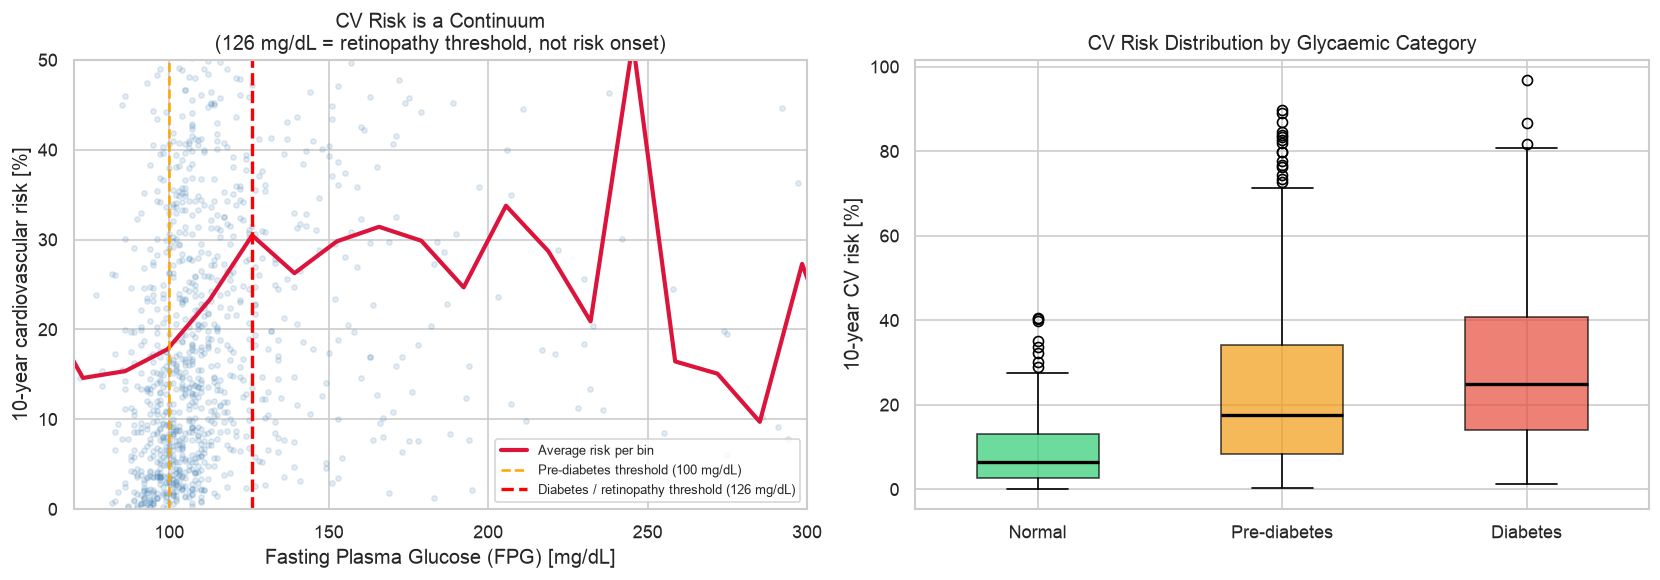

In [65]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

order = ["Normal", "Pre-diabetes", "Diabetes"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

# Left: FPG vs CV risk scatter + trend
n_sample = min(1100, df.dropna(subset = ["FPG", "cv_risk_10yr"]).shape[0])
sample = df.dropna(subset = ["FPG", "cv_risk_10yr"]).sample(n_sample, random_state = 42)

axes[0].scatter(sample["FPG"], sample["cv_risk_10yr"] * 100, alpha = 0.15, color = "steelblue", s = 10)

bins = pd.cut(sample["FPG"], bins = 30)
trend = sample.groupby(bins, observed = True)["cv_risk_10yr"].mean() * 100
bin_centers = [interval.mid for interval in trend.index]
axes[0].plot(bin_centers, trend.values, color = "crimson", linewidth = 2.5, label = "Average risk per bin")

axes[0].axvline(100, color = "orange", linestyle = "--", linewidth = 1.5,
                label = "Pre-diabetes threshold (100 mg/dL)")
axes[0].axvline(126, color = "red", linestyle = "--", linewidth = 2,
                label = "Diabetes / retinopathy threshold (126 mg/dL)")

axes[0].set_xlabel("Fasting Plasma Glucose (FPG) [mg/dL]", fontsize = 12)
axes[0].set_ylabel("10-year cardiovascular risk [%]", fontsize = 12)
axes[0].set_title("CV Risk is a Continuum\n(126 mg/dL = retinopathy threshold, not risk onset)",
                  fontsize = 12)
axes[0].legend(fontsize = 8)
axes[0].set_xlim(70, 300)
axes[0].set_ylim(0, 50)

# Right: Box plot by glycaemic category
data_plot = df.dropna(subset = ["glucose_status", "cv_risk_10yr"])
for i, (cat, col) in enumerate(zip(order, colors)):
    subset = data_plot[data_plot["glucose_status"] == cat]["cv_risk_10yr"] * 100
    axes[1].boxplot(subset.dropna(), positions = [i], widths = 0.5,
                    patch_artist = True,
                    boxprops = dict(facecolor = col, alpha = 0.7),
                    medianprops = dict(color = "black", linewidth = 2))

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(order, fontsize = 11)
axes[1].set_ylabel("10-year CV risk [%]", fontsize = 12)
axes[1].set_title("CV Risk Distribution by Glycaemic Category", fontsize = 12)

plt.tight_layout()
plt.savefig("../results/imgs/fig1-1_continuum_risk.png", bbox_inches="tight")
plt.show()


### 13. Visualisation 2 — LDL/Triglycerides & hs-CRP Stratification

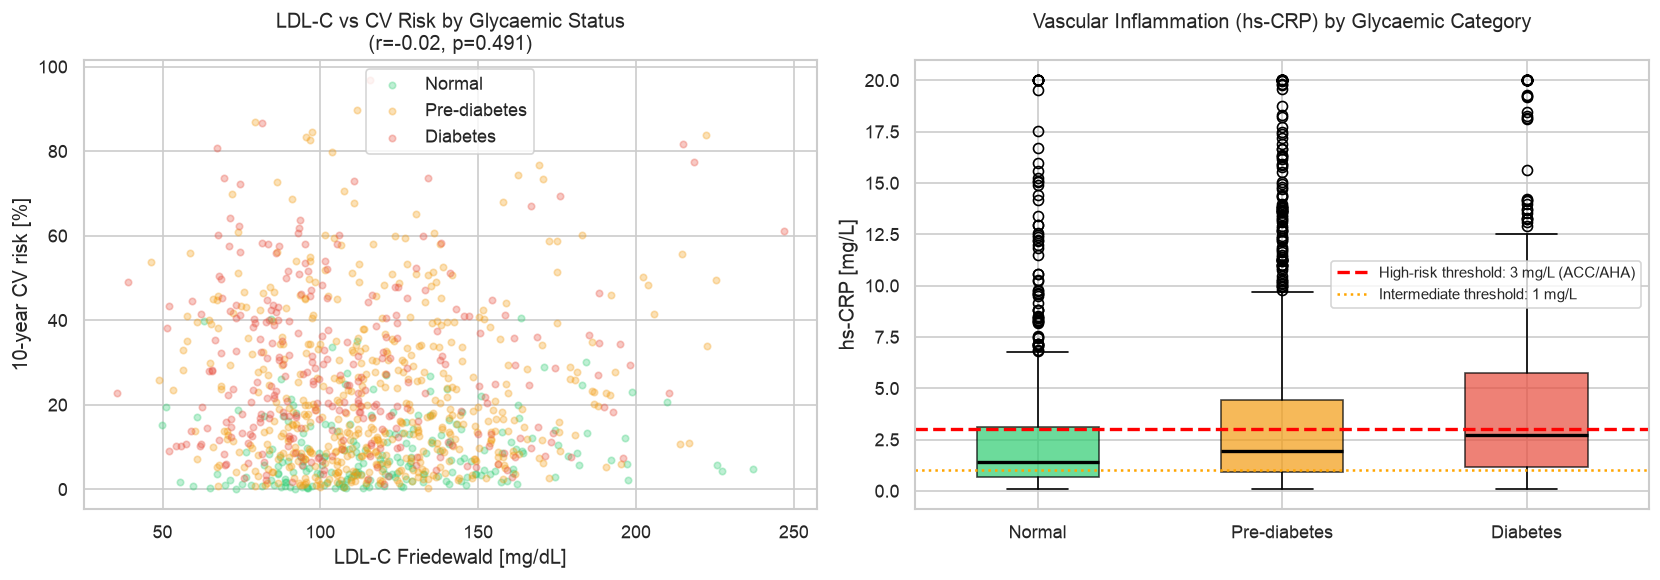

In [66]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Left: LDL vs CV risk by glycaemic status
for cat, col in zip(order, colors):
    sub = df[(df["glucose_status"] == cat)].dropna(subset = ["LDL", "cv_risk_10yr"])
    sub_sample = sub.sample(min(500, len(sub)), random_state = 42)
    axes[0].scatter(sub_sample["LDL"], sub_sample["cv_risk_10yr"] * 100,
                    alpha = 0.3, color = col, label = cat, s = 15)

# Pearson correlation
corr_df = df[["LDL", "cv_risk_10yr"]].dropna()
r, p = stats.pearsonr(corr_df["LDL"], corr_df["cv_risk_10yr"])
axes[0].set_xlabel("LDL-C Friedewald [mg/dL]", fontsize = 12)
axes[0].set_ylabel("10-year CV risk [%]", fontsize = 12)
axes[0].set_title(f"LDL-C vs CV Risk by Glycaemic Status\n(r={r:.2f}, p={'<0.001' if p<0.001 else f'{p:.3f}'})",
                  fontsize = 12)
axes[0].legend()

# Right: hs-CRP by glycaemic category + risk threshold
crp_data = [
    df[df["glucose_status"] == cat]["hs_CRP"].dropna().clip(0, 20)
    for cat in order
]
bp = axes[1].boxplot(crp_data, positions = [0,1,2], widths = 0.5, patch_artist = True,
                     medianprops = dict(color = "black", linewidth = 2))
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

axes[1].axhline(3, color = "red", linestyle = "--", linewidth = 2,
                label = "High-risk threshold: 3 mg/L (ACC/AHA)")
axes[1].axhline(1, color = "orange", linestyle = ":", linewidth = 1.5,
                label = "Intermediate threshold: 1 mg/L")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(order, fontsize = 11)
axes[1].set_ylabel("hs-CRP [mg/L]", fontsize = 12)
axes[1].set_title("Vascular Inflammation (hs-CRP) by Glycaemic Category\n",
                  fontsize = 12)
axes[1].legend(fontsize = 9)

plt.tight_layout()
plt.savefig("../results/imgs/fig1-2_ldl_crp.png", bbox_inches = "tight")
plt.show()


### 14. Visualisation 3 — PCE risk by demographic profile

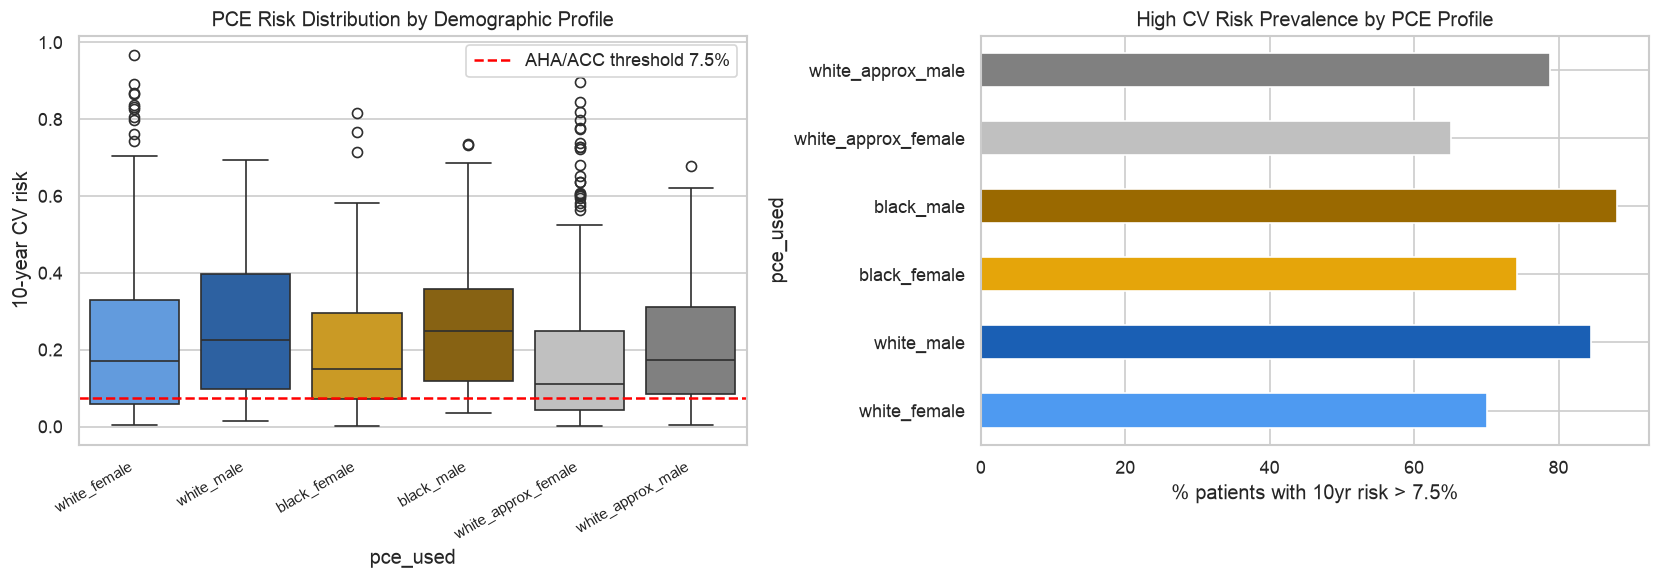

In [67]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

profile_order = ["white_female", "white_male",
                 "black_female", "black_male",
                 "white_approx_female", "white_approx_male"]
palette = {
    "white_female":        "#4e9af1",
    "white_male":          "#1a5fb4",
    "black_female":        "#e5a50a",
    "black_male":          "#9a6900",
    "white_approx_female": "#c0c0c0",
    "white_approx_male":   "#808080",
}

plot_data = df[df["pce_used"].isin(profile_order)].dropna(subset=["cv_risk_10yr"])
active_profiles = [p for p in profile_order if p in plot_data["pce_used"].unique()]

sns.boxplot(data=plot_data, x="pce_used", y="cv_risk_10yr",
            order=active_profiles, palette=palette, ax=axes[0])
axes[0].axhline(0.075, color="red", linestyle="--", label="AHA/ACC threshold 7.5%")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=9)
axes[0].set_ylabel("10-year CV risk")
axes[0].set_title("PCE Risk Distribution by Demographic Profile")
axes[0].legend()

high_risk_pct = (
    plot_data.groupby("pce_used")["high_cv_risk"]
    .mean().reindex(active_profiles) * 100
)
high_risk_pct.plot(kind="barh", ax=axes[1],
                   color=[palette.get(p, "gray") for p in high_risk_pct.index])
axes[1].set_xlabel("% patients with 10yr risk > 7.5%")
axes[1].set_title("High CV Risk Prevalence by PCE Profile")

plt.tight_layout()
plt.savefig("../results/imgs/fig1-3_pce_profiles.png", bbox_inches="tight")
plt.show()


### 15. ML Model — Random Forest extending PCE beyond age 40-79

**Strategy**:

- Train on patients with **valid PCE** (40-79 years): the model learns to replicate the clinical formula
- Predict on **all patients**: extends risk estimation to ages not covered by PCE
- Includes `fpg_slope` as a trajectory feature
- Uses calibrated probabilities so outputs are comparable to PCE percentages


In [68]:
features = [
    "age", "sex", "ethnicity",
    "FPG", "HbA1c", "fpg_slope",        # trajectory feature
    "total_chol", "HDL", "LDL", "triglycerides",
    "systolic_bp", "diastolic_bp",
    "BMI", "hs_CRP",
    "ever_smoked", "on_bp_meds",
    "marker_stability",                    # A1C vs FPG reliability
]

# Full dataset: drop only rows missing features
extra_cols = [c for c in ["high_cv_risk", "high_cv_risk_crp", "pce_valid", "cv_risk_10yr"]
              if c not in features]
df_ml_full = df[features + extra_cols].copy()
df_ml_full = df_ml_full.dropna(subset=features)

# Training subset: only PCE-valid patients (gold-standard labels)
df_ml_pce  = df_ml_full[df_ml_full["pce_valid"] & df_ml_full["high_cv_risk_crp"].notna()]
df_ml_nopce = df_ml_full[~df_ml_full["pce_valid"]]

print("="*40)
print(f"  Training set (PCE-valid):  {len(df_ml_pce):>6}")
print(f"  Out-of-range (no PCE):     {len(df_ml_nopce):>6}")
print(f"  Total with full features:  {len(df_ml_full):>6}")
print("="*40)
print(f"  High-risk prevalence (train): {df_ml_pce['high_cv_risk_crp'].mean()*100:.1f}%")

X_pce = df_ml_pce[features]
y_pce = df_ml_pce["high_cv_risk_crp"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_pce, y_pce, test_size=0.2, random_state=42, stratify=y_pce)

test_idx = X_test.index

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight="balanced", random_state=42, n_jobs=-1)

rf = CalibratedClassifierCV(rf_base, method="isotonic", cv=5)
rf.fit(X_train_s, y_train)

cv_scores = cross_val_score(
    rf, X_train_s, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc")
print(f"\nAUC cross-validation (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

y_pred_proba = rf.predict_proba(X_test_s)[:, 1]
y_pred       = rf.predict(X_test_s)
auc   = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)
print(f"AUC-ROC test set:   {auc:.3f}")
print(f"Brier score:        {brier:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Low risk', 'High risk'])}")

# Predict on ALL patients
X_full_s = scaler.transform(df_ml_full[features])
df_ml_full = df_ml_full.copy()
df_ml_full["rf_risk_proba"] = rf.predict_proba(X_full_s)[:, 1]
df_ml_full["rf_high_risk"]  = rf.predict(X_full_s)

df = df.merge(df_ml_full[["rf_risk_proba", "rf_high_risk"]],
              left_index=True, right_index=True, how="left")


  Training set (PCE-valid):     503
  Out-of-range (no PCE):        200
  Total with full features:     703
  High-risk prevalence (train): 92.2%

AUC cross-validation (5-fold): 0.940 ± 0.029
AUC-ROC test set:   0.806
Brier score:        0.063

              precision    recall  f1-score   support

    Low risk       0.50      0.38      0.43         8
   High risk       0.95      0.97      0.96        93

    accuracy                           0.92       101
   macro avg       0.72      0.67      0.69       101
weighted avg       0.91      0.92      0.92       101



### 16. Visualisation 4 — Model performance & PCE vs ML extension

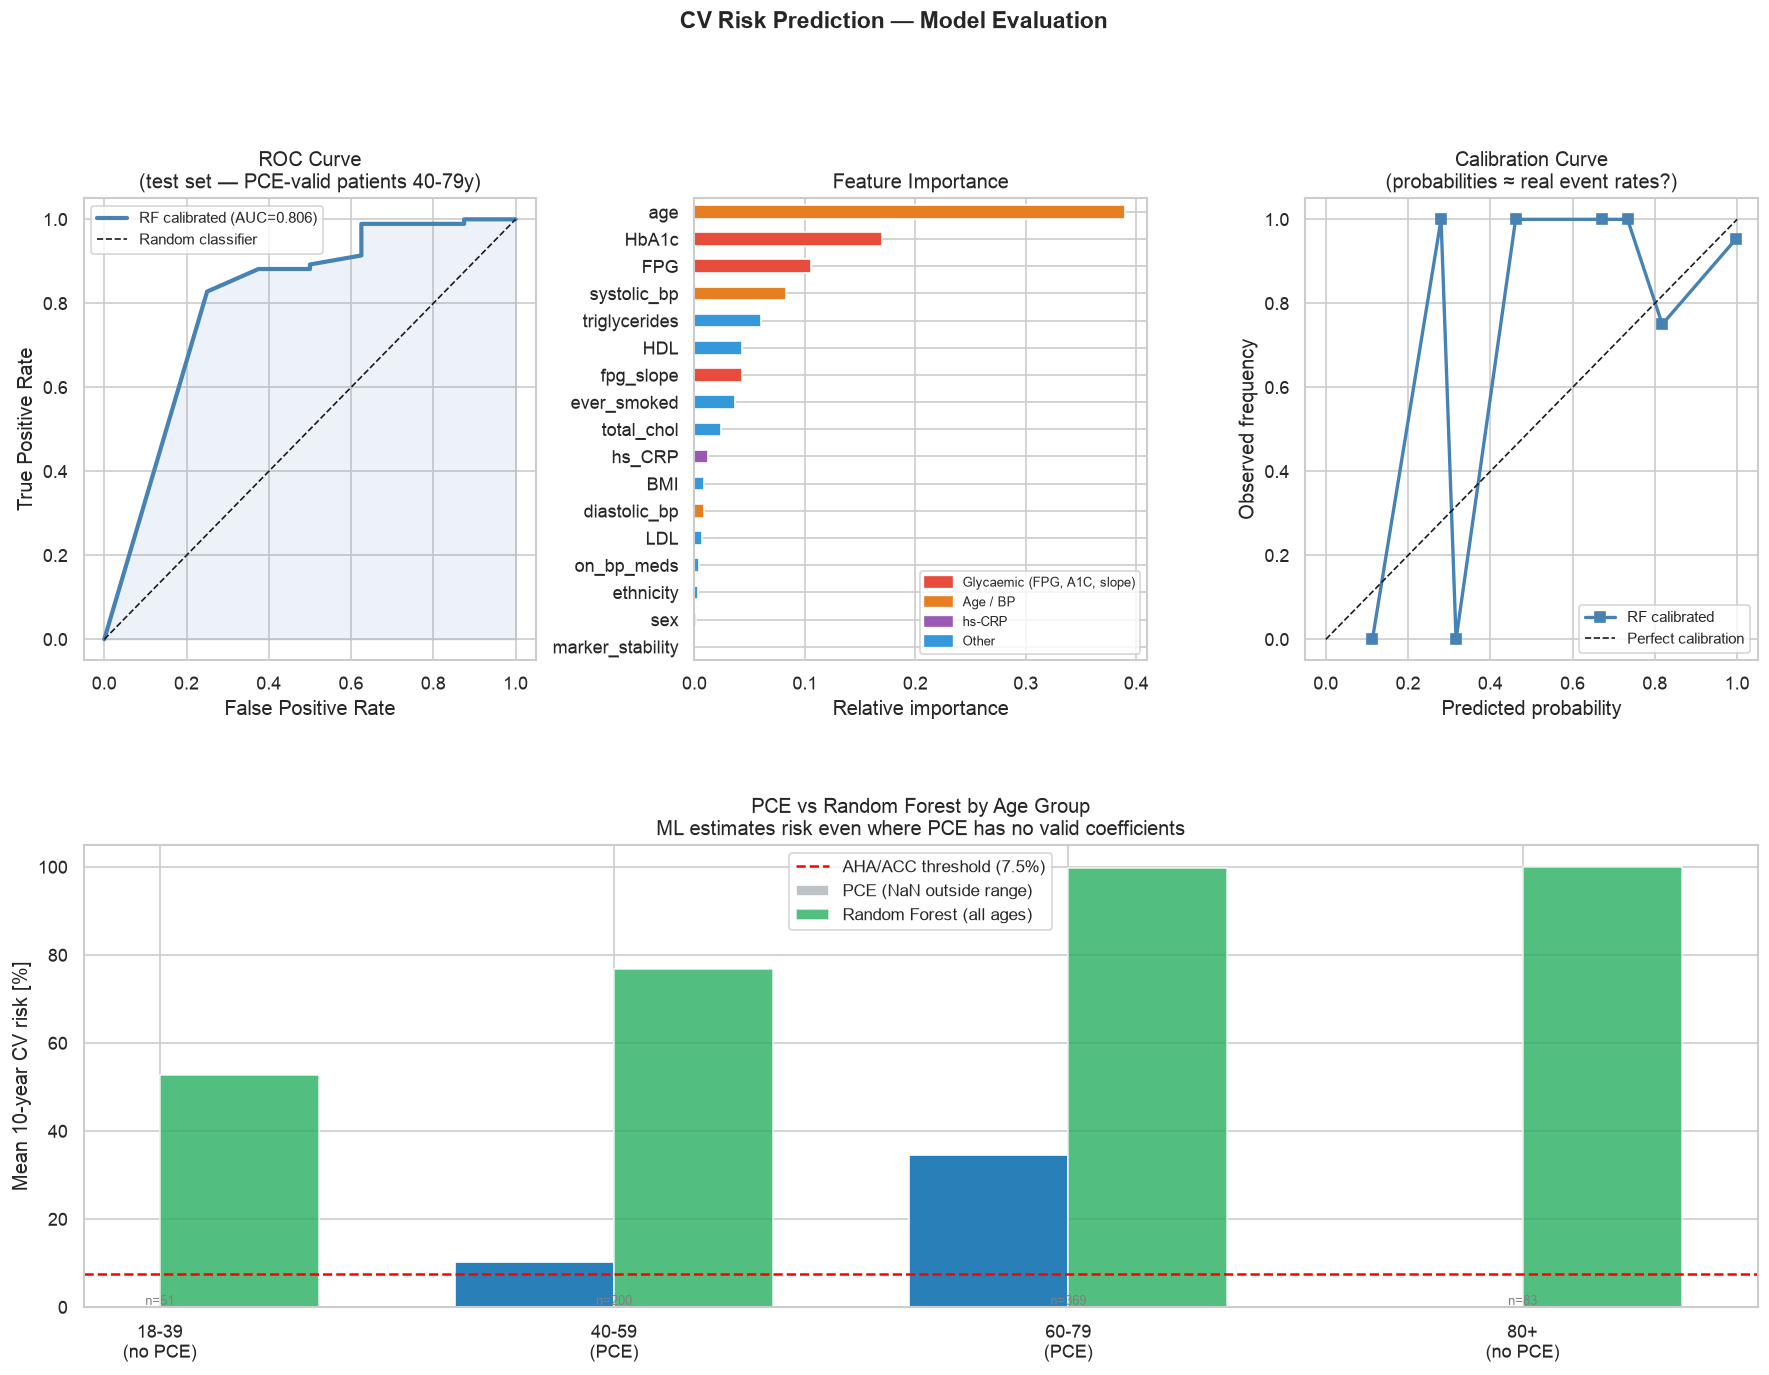

In [69]:
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :])

# ── 1. ROC curve ─────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax1.plot(fpr, tpr, color="steelblue", lw=2.5, label=f"RF calibrated (AUC={auc:.3f})")
ax1.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax1.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve\n(test set — PCE-valid patients 40-79y)")
ax1.legend(fontsize=9)

# ── 2. Feature importance ────────────────────────────────
base_rf = rf.calibrated_classifiers_[0].estimator
importances = pd.Series(base_rf.feature_importances_, index=features).sort_values(ascending=True)
colors_bar = [
    "#e74c3c" if f in ["FPG", "HbA1c", "fpg_slope"] else
    "#e67e22" if f in ["age", "systolic_bp", "diastolic_bp"] else
    "#9b59b6" if f == "hs_CRP" else
    "#3498db"
    for f in importances.index
]
importances.plot(kind="barh", ax=ax2, color=colors_bar)
ax2.set_title("Feature Importance")
ax2.set_xlabel("Relative importance")
ax2.legend(handles=[
    Patch(color="#e74c3c", label="Glycaemic (FPG, A1C, slope)"),
    Patch(color="#e67e22", label="Age / BP"),
    Patch(color="#9b59b6", label="hs-CRP"),
    Patch(color="#3498db", label="Other"),
], fontsize=8, loc="lower right")

# ── 3. Calibration curve ─────────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
ax3.plot(prob_pred, prob_true, "s-", color="steelblue", lw=2,
         label="RF calibrated")
ax3.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
ax3.set_xlabel("Predicted probability")
ax3.set_ylabel("Observed frequency")
ax3.set_title("Calibration Curve\n(probabilities ≈ real event rates?)")
ax3.legend(fontsize=9)

# ── 4. PCE vs RF by age group ────────────────────────────
bins_age   = [18, 39, 59, 79, 100]
labels_age = ["18-39\n(no PCE)", "40-59\n(PCE)", "60-79\n(PCE)", "80+\n(no PCE)"]
df["age_group"] = pd.cut(df["age"], bins=bins_age, labels=labels_age, right=True)

age_stats = df.groupby("age_group", observed=True).agg(
    pce_mean  =("cv_risk_10yr",  "mean"),
    ml_mean   =("rf_risk_proba", "mean"),
    count     =("rf_risk_proba", "count")
).reset_index()

x = np.arange(len(age_stats))
w = 0.35
bars1 = ax4.bar(x - w/2, age_stats["pce_mean"]*100, w,
                label="PCE (NaN outside range)",
                color=["#bdc3c7" if "no" in str(g) else "#2980b9"
                       for g in age_stats["age_group"]], edgecolor="white")
bars2 = ax4.bar(x + w/2, age_stats["ml_mean"]*100, w,
                label="Random Forest (all ages)",
                color="#27ae60", alpha=0.8, edgecolor="white")

for i, row_s in age_stats.iterrows():
    ax4.text(i, 0.5, f"n={int(row_s['count'])}", ha="center", fontsize=8, color="gray")

ax4.axhline(7.5, color="red", linestyle="--", lw=1.5, label="AHA/ACC threshold (7.5%)")
ax4.set_xticks(x)
ax4.set_xticklabels(age_stats["age_group"], fontsize=11)
ax4.set_ylabel("Mean 10-year CV risk [%]")
ax4.set_title("PCE vs Random Forest by Age Group\n"              "ML estimates risk even where PCE has no valid coefficients", fontsize=12)
ax4.legend(fontsize=10)

plt.suptitle("CV Risk Prediction — Model Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("../results/imgs/fig1-4_model_performance.png", bbox_inches="tight")
plt.show()
